# Crime Schema and Data Quality

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

import pandas as pd
from crime_snapshot import load_crime_snapshot
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

df, metadata = load_crime_snapshot(
    PROJECT_ROOT / "data" / "processed" / "crime"
)

display(df.head())

,report_number,report_date_time,offense_id,offense_date,nibrs_group_a_b,nibrs_crime_against_category,offense_sub_category,shooting_type_group,block_address,latitude,longitude,beat,precinct,sector,neighborhood,reporting_area,offense_category,nibrs_offense_code_description,nibrs_offense_code,census_block_2020
0,2025-216626,2025-07-30 21:29:01,65206207604,2025-07-30 19:40:00,a,person,aggravated assault,-,NW DOCK PL / RUSSELL AVE NW,47.665332,-122.379171,b1,north,b,ballard south,2582,violent crime,aggravated assault,13A,4701.3010
1,2025-216626,2025-07-30 21:29:01,65206263407,2025-07-30 19:40:00,a,property,motor vehicle theft,-,NW DOCK PL / RUSSELL AVE NW,47.665332,-122.379171,b1,north,b,ballard south,2582,property crime,motor vehicle theft,240,4701.3010
2,2025-216626,2025-07-30 21:29:01,65206225388,2025-07-30 19:40:00,a,property,"property offenses (includes stolen, destruction)",-,NW DOCK PL / RUSSELL AVE NW,47.665332,-122.379171,b1,north,b,ballard south,2582,all other,destruction/damage/vandalism of property,290,4701.3010
3,2025-216641,2025-07-30 20:39:42,65205847305,2025-07-30 19:50:00,a,property,larceny-theft,-,2XX BLOCK OF YALE AVE N,47.620244,-122.330420,d3,west,d,slu/cascade,3164,property crime,shoplifting,23C,7301.1005
4,2025-217214,2025-07-31 10:52:13,65214639215,2025-07-30 20:00:00,a,property,"property offenses (includes stolen, destruction)",-,79XX BLOCK OF 46TH AVE S,47.530306,-122.274475,s2,south,s,brighton/dunlap,402,all other,destruction/damage/vandalism of property,290,11801.2004


In [10]:
print("Date range of offense_date: ")
print(str(df["offense_date"].min())[:10] + " to " + str(df["offense_date"].max())[:10])
print("Date range of report_date_time: ")
print(str(df["report_date_time"].min())[:10] + " to " + str(df["report_date_time"].max())[:10])
display(df.describe())

Date range of offense_date: 
2025-07-30 to 2026-07-30
Date range of report_date_time: 
2023-12-18 to 2026-07-31


,report_date_time,offense_date,latitude,longitude
count,77307,77307,65028.000000,65028.000000
mean,2026-01-29 07:14:20.002432,2026-01-24 09:21:00.584423,47.021041,-120.829685
min,2023-12-18 03:50:23,2025-07-30 19:40:00,-1.000000,-122.432252
25%,2025-10-29 09:35:09,2025-10-23 11:00:00,47.597509,-122.349214
50%,2026-01-29 07:39:10,2026-01-20 08:00:00,47.616945,-122.329221
75%,2026-05-03 08:43:57.500000,2026-04-28 09:37:00,47.662199,-122.313277
max,2026-07-31 00:10:29,2026-07-30 19:35:00,47.777783,-1.000000
std,NaN,NaN,5.376595,13.415951


offense_id is unique: True
Head of offense_id frequencies: 
offense_id
65206207604    1
65206263407    1
65206225388    1
65205847305    1
65214639215    1
Name: count, dtype: int64[pyarrow]
report_number is unique: False


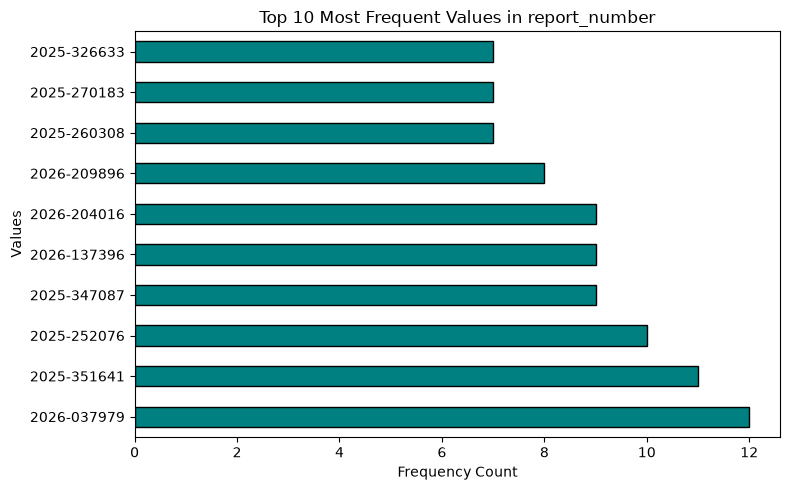

In [12]:
print(f"offense_id is unique: {df['offense_id'].is_unique}")
print(f"Head of offense_id frequencies: \n{df['offense_id'].value_counts().head(5)}")
print(f"report_number is unique: {df['report_number'].is_unique}")

# 3. Create a Distribution Chart of Unique vs. Duplicate Counts
plt.figure(figsize=(8, 5))
value_counts = df['report_number'].value_counts()
value_counts.head(10).plot(kind='barh', color='teal', edgecolor='black')
plt.title(f'Top 10 Most Frequent Values in report_number')
plt.xlabel('Frequency Count')
plt.ylabel('Values')
plt.tight_layout()
plt.show()


In [14]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_frame = pd.DataFrame(missing, index=None).reset_index()

missing_frame['percent_missing'] = ((missing_frame[0] / len(df)) * 100).round(2)
missing_frame['percent_missing'] = missing_frame['percent_missing'].astype(str) + '%'
headers = ['feature', 'number_missing', 'percent_missing']
missing_frame.columns = headers

#print("\n Missing Values in  Data:")
#display(missing_frame)

fig = px.bar(
    missing_frame,
    x="number_missing",
    y="feature",
    orientation='h',
    color="number_missing",          
    color_continuous_scale='Reds',
    labels={'number_missing': 'Number of Missing Values', 'feature': 'Features', 'percent_missing':'Percent Missing '},
    title='Missing Values in Data',
    hover_data={
        "number_missing": False,
        "feature": False,
        "percent_missing": True,
    },
)

fig.update_layout(
    template="plotly_dark",
    width=1200,
    height=800,
    coloraxis_showscale=False,
    title_font_size=24,
    title_x=0.532,
    title_y=.95,
    title_xanchor='center',
    margin=dict(t=150), 
    xaxis=dict(
        title_standoff=30,  
        tickangle=0,
        ticklabelstandoff=0, 
    ),
    yaxis=dict(
        tickangle=-45,
        title_standoff=30,   
        ticklabelstandoff=10,
    ),
    annotations=[
        dict(text=f"Latitude and Longitude have the same number of missing values in the past year {missing_frame['number_missing'][0]} and {missing_frame['percent_missing'][0]} of all coordinates are missing in this snapshot",
            xref="paper", yref="paper",
            x=.485, y=1.14,    
            showarrow=False,
            font=dict(size=10, color="darkgray"),
            xanchor="center")
        ]
    
)

fig.update_traces(
    hovertemplate="Percent Missing = %{customdata[0]}<extra></extra>"
)

fig.show()


In [18]:
from IPython.display import HTML, display

df["has_coordinates"] = (
    df["latitude"].notna()
    & df["longitude"].notna()
)

coordinate_by_event_group = (
    df
    .groupby("offense_sub_category")
    .agg(
        total_calls=("offense_id", "size"),
        mappable_calls=("has_coordinates", "sum"),
    )
    .reset_index()
)

coordinate_by_event_group["mappable_percent"] = (
    coordinate_by_event_group["mappable_calls"]
    / coordinate_by_event_group["total_calls"]
    * 100
).round(2)

completely_unmappable = coordinate_by_event_group[coordinate_by_event_group["mappable_percent"] == 0]["offense_sub_category"].tolist()
completely_unmappable = coordinate_by_event_group["offense_sub_category"].str.replace(r'\s*\([^)]*\)', '', regex=True).tolist()

completely_unmappable = (
    coordinate_by_event_group[
        coordinate_by_event_group["mappable_percent"] == 0
    ]["offense_sub_category"]
    .astype("string")
    .str.replace(r"\s*\([^)]*\)", "", regex=True)
    .tolist()
)


missing_plot_df = coordinate_by_event_group[(coordinate_by_event_group["mappable_percent"] < 33) & (coordinate_by_event_group["mappable_percent"] > 0)].sort_values(
    "mappable_percent",
    ascending=True,
)

fig = px.bar(
    missing_plot_df,
    x="offense_sub_category",
    y="mappable_percent",
    title="Event Groups with Low Coordinate Coverage",
    width=1200,   
    height=800,   
)

fig.update_traces(marker_color="salmon")
fig.update_layout(title_x=0.5)

fig.update_layout(
    template="plotly_dark",
    xaxis_title="Event Group",
    yaxis_title="Percent of Calls with Coordinates",
    
    title_font=dict(size=24),
    
    margin=dict(
        l=120,    
        r=120,    
        t=160,    
        b=160,    
    ),
    
    xaxis=dict(
        title_standoff=50,  
        tickangle=0,
        ticklabelstandoff=18,
    ),
    yaxis=dict(
        title_standoff=50,   
        ticklabelstandoff=10,
        ticksuffix="%",
    ),
    annotations=[
        dict(text=f"Note: The following event groups have 0% mappable calls: {', '.join(completely_unmappable[:8])} <br> {', '.join(completely_unmappable[8:20])} <br> {', '.join(completely_unmappable[20:29])} <br> {', '.join(completely_unmappable[29:39])} <br> {', '.join(completely_unmappable[39:])}",
            xref="paper", yref="paper",
            x=.50, y=1.14,    
            showarrow=False,
            font=dict(size=9, color="darkgray"),
            xanchor="center")
        ]
)

# 4. Display the plot
fig.show()

